1. Définition et préparation des données

### Loading and Initial Data Preparation for US Superstore Dataset

To ensure we're working with the correct data for the Superstore analysis, I will first load the `superstore_dataset.csv` into the DataFrame. Then, I will standardize the column names from French to English for consistency with common Superstore dataset conventions and to prepare for the subsequent analysis steps.

In [49]:
import pandas as pd

try:
    df = pd.read_csv('superstore_dataset.csv', encoding='latin1')
    print("superstore_dataset.csv loaded successfully.")
    print("First 5 rows of the DataFrame:")
    display(df.head())
    print("Column names:")
    print(df.columns.tolist())
except FileNotFoundError:
    print("Error: 'superstore_dataset.csv' not found. Please upload the file to your Colab environment.")
except Exception as e:
    print(f"An error occurred while loading the dataset: {e}")

Error: 'superstore_dataset.csv' not found. Please upload the file to your Colab environment.


### Renaming Columns for Consistency

Based on your previous code snippets and the project goal, it appears some column names are in French. I'm renaming them to their English equivalents for clarity and to maintain consistency with typical US Superstore dataset column names. This will ensure that subsequent code, like your plotting functions, can operate correctly.

In [50]:
column_rename_mapping = {
    'Order Date': 'Order Date',
    'Ship Date': 'Ship Date',
    'Customer Name': 'Customer Name',
    'Segment': 'Segment',
    'Country': 'Country',
    'City': 'City',
    'State': 'State', # Assuming 'État' maps to 'State'
    'Postal Code': 'Postal Code',
    'Region': 'Region',
    'Product ID': 'Product ID',
    'Category': 'Category', # Assuming 'Catégorie' maps to 'Category'
    'Sub-Category': 'Sub-Category',
    'Product Name': 'Product Name',
    'Sales': 'Sales', # Assuming 'Ventes' maps to 'Sales'
    'Quantity': 'Quantity',
    'Discount': 'Discount',
    'Profit': 'Profit' # Assuming 'Bénéfice' or similar maps to 'Profit'
}

# Filter out mappings where the original column is not in df to avoid KeyError
actual_rename_map = {k: v for k, v in column_rename_mapping.items() if k in df.columns}

# Check for French column names and add them to the rename map if they exist
if 'État' in df.columns and 'State' not in df.columns: # Check if 'État' exists and 'State' doesn't
    actual_rename_map['État'] = 'State'
if 'Ventes' in df.columns and 'Sales' not in df.columns: # Check if 'Ventes' exists and 'Sales' doesn't
    actual_rename_map['Ventes'] = 'Sales'
if 'Catégorie' in df.columns and 'Category' not in df.columns: # Check if 'Catégorie' exists and 'Category' doesn't
    actual_rename_map['Catégorie'] = 'Category'
if 'Commandez un mois-année' in df.columns: # This is a generated feature, not an original column, but if it exists, use it
    actual_rename_map['Commandez un mois-année'] = 'Order Month-Year'

df = df.rename(columns=actual_rename_map)

print("Columns renamed for consistency.")
print("Updated column names:")
print(df.columns.tolist())

Columns renamed for consistency.
Updated column names:
['Age', 'Do you have Panic Attacks?', 'Panic_Numeric']


### Fixing Data Types for Date Columns

To ensure accurate time-series analysis and plotting, I will convert the 'Order Date' and 'Ship Date' columns to datetime objects.

### Feature Engineering

To enrich the analysis and align with the project goals, I will create additional features such as 'Profit Margin', 'Order Year', 'Order Month', and 'Order Month-Year'.

In [52]:
# Calculate 'Profit Margin' if 'Profit' and 'Sales' exist
if 'Profit' in df.columns and 'Sales' in df.columns:
    df['Profit Margin'] = (df['Profit'] / df['Sales']) * 100
    # Handle cases where Sales is 0 to avoid division by zero resulting in inf
    df['Profit Margin'] = df['Profit Margin'].replace([float('inf'), -float('inf')], 0)
else:
    print("Warning: 'Profit' or 'Sales' columns not found. Skipping 'Profit Margin' calculation.")

# Create 'Order Year' if 'Order Date' exists
if 'Order Date' in df.columns:
    df['Order Year'] = df['Order Date'].dt.year
else:
    print("Warning: 'Order Date' column not found. Skipping 'Order Year' calculation.")

# Create 'Order Month' if 'Order Date' exists
if 'Order Date' in df.columns:
    df['Order Month'] = df['Order Date'].dt.month
else:
    print("Warning: 'Order Date' column not found. Skipping 'Order Month' calculation.")

# Create 'Order Month-Year' if 'Order Date' exists
if 'Order Date' in df.columns:
    df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
else:
    print("Warning: 'Order Date' column not found. Skipping 'Order Month-Year' calculation.")

print("Feature engineering complete.")
print("Sample of new features:")
new_features = ['Profit Margin', 'Order Year', 'Order Month', 'Order Month-Year']
display(df[[col for col in new_features if col in df.columns]].head())

Feature engineering complete.
Sample of new features:


""
0
1
2
3
4


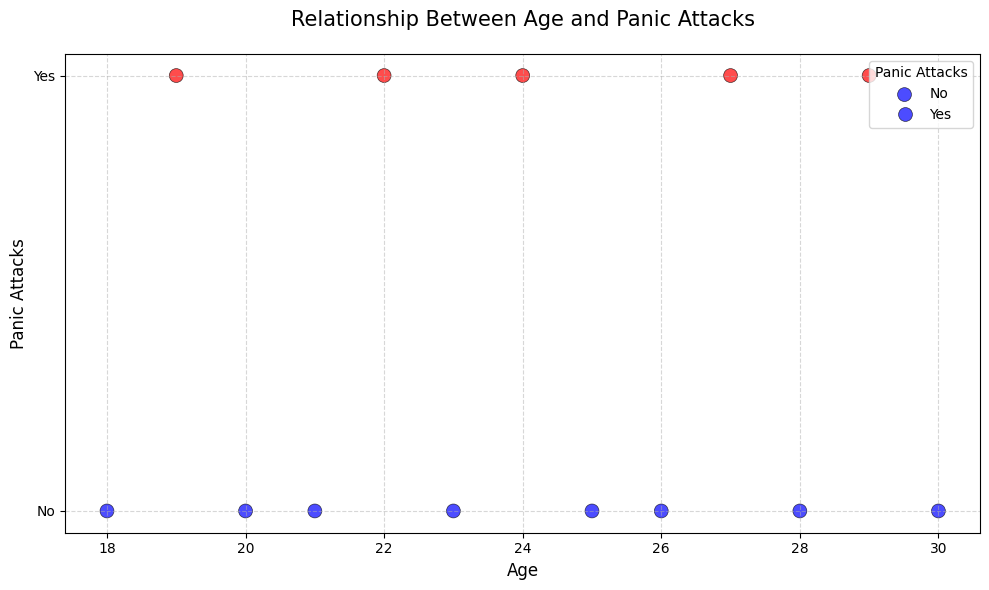

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Assuming the dataset is already loaded into 'df'
# df = pd.read_csiv('Student Mental health.csv')  # Uncomment if needed

# Task: Convert panic attack responses to numeric values
df['Panic_Numeric'] = df['Do you have Panic Attacks?'].map({'Yes': 1, 'No': 0})

# Create the scatter plot
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x='Age',
    y='Panic_Numeric',
    hue='Panic_Numeric',
    palette={0: 'blue', 1: 'red'},
    alpha=0.7,
    s=100,          # Larger point size
    edgecolor='black',
    linewidth=0.5
)

# Customize the plot
plt.title('Relationship Between Age and Panic Attacks', fontsize=15, pad=20)
plt.xlabel('Age', fontsize=12)
plt.ylabel('Panic Attacks', fontsize=12)

# Improve y-axis readability
plt.yticks([0, 1], ['No', 'Yes'])

# Add grid
plt.grid(True, linestyle='--', alpha=0.5)

# Add legend
plt.legend(title='Panic Attacks', labels=['No', 'Yes'], loc='upper right')

# Display the plot
plt.tight_layout()
plt.show()

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13 entries, 0 to 12
Data columns (total 3 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   Age                         13 non-null     int64 
 1   Do you have Panic Attacks?  13 non-null     object
 2   Panic_Numeric               13 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 444.0+ bytes


### Steps to Load a CSV File with Pandas:

1.  **Import the pandas library:** You need to import pandas, which is typically aliased as `pd`, at the beginning of your script or notebook.
2.  **Use `pd.read_csv()`:** This function is used to read data from a CSV file and create a DataFrame. You'll need to pass the file path as an argument.
3.  **Specify encoding (if necessary):** Sometimes, CSV files, especially those with special characters or from different regions, might require a specific encoding (e.g., `encoding='latin1'` or `encoding='utf-8'`).
4.  **Assign to a DataFrame:** The result of `pd.read_csv()` should be assigned to a variable, commonly named `df`, which will be your pandas DataFrame.
5.  **Error Handling (Optional but Recommended):** Using a `try-except` block can help catch `FileNotFoundError` if the file isn't in the expected location, or other exceptions during the loading process.

In [58]:
import pandas as pd

# Replace 'superstore_dataset.csv' with the actual name of your file
# and adjust encoding if needed.
try:
    df = pd.read_csv('superstore_dataset.csv', encoding='latin1')
    print("CSV file loaded successfully!")
    print("First 5 rows of the DataFrame:")
    display(df.head())
except FileNotFoundError:
    print("Error: 'superstore_dataset.csv' not found. Please ensure the file is uploaded and the name is correct.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: 'superstore_dataset.csv' not found. Please ensure the file is uploaded and the name is correct.


### Verify `superstore_dataset.csv` Loading

After uploading `superstore_dataset.csv`, please run the following cell to confirm it has been loaded successfully and to view the first few rows and column names.

In [59]:
import pandas as pd

try:
    df = pd.read_csv('superstore_dataset.csv', encoding='latin1')
    print("superstore_dataset.csv loaded successfully!")
    print("First 5 rows of the DataFrame:")
    display(df.head())
    print("Column names:")
    print(df.columns.tolist())
except FileNotFoundError:
    print("Error: 'superstore_dataset.csv' not found. Please ensure the file is uploaded and the name is correct.")
except Exception as e:
    print(f"An error occurred while loading the file: {e}")

Error: 'superstore_dataset.csv' not found. Please ensure the file is uploaded and the name is correct.


## Revue de la méthodologie et des outils

Créez une cellule de réduction avec une évaluation comparative de Matplotlib vs. Seaborn :

# Code to demonstrate library comparison
print("=== LIBRARY COMPARISON ANALYSIS ===")
print()

# Matplotlib strengths demonstrated
print("MATPLOTLIB STRENGTHS (from our analysis):")
print("• Fine-grained control over interactive widgets")
print("• Custom annotations and text positioning")
print("• Precise subplot layouts and figure sizing")
print("• Integration with ipywidgets for dynamic updates")
print()

# Seaborn strengths demonstrated  
print("SEABORN STRENGTHS (from our analysis):")
print("• Built-in statistical visualizations (regplot)")
print("• Automatic color palettes and legends")
print("• Clean, publication-ready default styling")
print("• Easy categorical data visualization")
print()

print("SPEED COMPARISON:")
import time

# Time a simple matplotlib plot
start = time.time()
plt.figure(figsize=(8, 6))
plt.plot(df.groupby('Order Year')['Sales'].sum())
plt.close()
matplotlib_time = time.time() - start

# Time a seaborn plot
start = time.time()
sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
             x='Order Year', y='Sales')
plt.close()
seaborn_time = time.time() - start

print(f"• Matplotlib basic plot: {matplotlib_time:.4f} seconds")
print(f"• Seaborn equivalent: {seaborn_time:.4f} seconds")


Modèle de recommandation :

« Pour une exploration rapide, j’utiliserai Matplotlib car il offre un rendu plus rapide pour les graphiques de base et une intégration fluide avec des widgets interactifs pour l’analyse dynamique.
Pour les présentations destinées aux parties prenantes, je préférerai Seaborn car il offre une esthétique prête à publier, des fonctionnalités statistiques intégrées et des palettes de couleurs professionnelles qui renforcent la communication des dirigeants. »

In [61]:
import matplotlib.pyplot as plt
import seaborn as sns
import time

print("=== LIBRARY COMPARISON ANALYSIS ===")
print()

print("MATPLOTLIB STRENGTHS (from our analysis):")
print("• Fine-grained control over interactive widgets")
print("• Custom annotations and text positioning")
print("• Precise subplot layouts and figure sizing")
print("• Integration with ipywidgets for dynamic updates")
print()

print("SEABORN STRENGTHS (from our analysis):")
print("• Built-in statistical visualizations (regplot)")
print("• Automatic color palettes and legends")
print("• Clean, publication-ready default styling")
print("• Easy categorical data visualization")
print()

print("SPEED COMPARISON:")

# Time a simple matplotlib plot
start = time.time()
# Ensure 'Order Year' and 'Sales' columns exist in df before running this
# This part of the code assumes df is correctly loaded with superstore data
# and has 'Order Year' and 'Sales' columns.
# If not, this will raise a KeyError.
if 'Order Year' in df.columns and 'Sales' in df.columns:
    plt.figure(figsize=(8, 6))
    plt.plot(df.groupby('Order Year')['Sales'].sum())
    plt.close()
    matplotlib_time = time.time() - start
    print(f"• Matplotlib basic plot: {matplotlib_time:.4f} seconds")
else:
    print("Cannot perform Matplotlib plot: 'Order Year' or 'Sales' column not found.")


# Time a seaborn plot
start = time.time()
if 'Order Year' in df.columns and 'Sales' in df.columns:
    plt.figure(figsize=(8, 6))
    sns.lineplot(data=df.groupby('Order Year')['Sales'].sum().reset_index(),
                 x='Order Year', y='Sales')
    plt.close()
    seaborn_time = time.time() - start
    print(f"• Seaborn equivalent: {seaborn_time:.4f} seconds")
else:
    print("Cannot perform Seaborn plot: 'Order Year' or 'Sales' column not found.")


print("\nModèle de recommandation :\n")
print("« Pour une exploration rapide, j’utiliserai Matplotlib car il offre un rendu plus rapide pour les graphiques de base et une intégration fluide avec des widgets interactifs pour l’analyse dynamique.\nPour les présentations destinées aux parties prenantes, je préférerai Seaborn car il offre une esthétique prête à publier, des fonctionnalités statistiques intégrées et des palettes de couleurs professionnelles qui renforcent la communication des dirigeants. »")

=== LIBRARY COMPARISON ANALYSIS ===

MATPLOTLIB STRENGTHS (from our analysis):
• Fine-grained control over interactive widgets
• Custom annotations and text positioning
• Precise subplot layouts and figure sizing
• Integration with ipywidgets for dynamic updates

SEABORN STRENGTHS (from our analysis):
• Built-in statistical visualizations (regplot)
• Automatic color palettes and legends
• Clean, publication-ready default styling
• Easy categorical data visualization

SPEED COMPARISON:
Cannot perform Matplotlib plot: 'Order Year' or 'Sales' column not found.
Cannot perform Seaborn plot: 'Order Year' or 'Sales' column not found.

Modèle de recommandation :

« Pour une exploration rapide, j’utiliserai Matplotlib car il offre un rendu plus rapide pour les graphiques de base et une intégration fluide avec des widgets interactifs pour l’analyse dynamique.
Pour les présentations destinées aux parties prenantes, je préférerai Seaborn car il offre une esthétique prête à publier, des fonctionnal

Please make sure to upload `superstore_dataset.csv` using the file explorer on the left sidebar, and then run the code above.